# Exercice 1.3 — Analyses multivariées et corrélations sur Ames Housing

Dans ce notebook, je poursuis l'analyse autour de trois hypothèses fortes pour l'oral :

- **la qualité du bien** (`Overall Qual`) influence fortement le prix ;
- **la surface habitable** (`Gr Liv Area`) influence le prix ;
- **la localisation** (`Neighborhood`) module la relation entre caractéristiques du bien et prix.

L'objectif ici est de montrer que ces variables restent importantes même dans une lecture multivariée.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
df = pd.read_csv('AmesHousing.csv')

## 1. Matrices de corrélation : Pearson et Spearman

In [2]:
vars_num = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Year Remod/Add', 'Garage Cars', 'Garage Area', 'Total Bsmt SF']
d = df[vars_num].dropna()

pearson_corr = d.corr(method='pearson')
spearman_corr = d.corr(method='spearman')

pearson_sale = pearson_corr['SalePrice'].sort_values(ascending=False)
spearman_sale = spearman_corr['SalePrice'].sort_values(ascending=False)

print("Pearson avec SalePrice :")
print(pearson_sale)
print("\nSpearman avec SalePrice :")
print(spearman_sale)

Pearson avec SalePrice :
SalePrice         1.000000
Overall Qual      0.799765
Gr Liv Area       0.699664
Garage Cars       0.643888
Garage Area       0.637255
Total Bsmt SF     0.629235
Year Built        0.559844
Year Remod/Add    0.531101
Lot Area          0.269107
Name: SalePrice, dtype: float64

Spearman avec SalePrice :
SalePrice         1.000000
Overall Qual      0.814180
Gr Liv Area       0.715754
Garage Cars       0.703563
Year Built        0.688908
Garage Area       0.662782
Total Bsmt SF     0.617147
Year Remod/Add    0.599426
Lot Area          0.429383
Name: SalePrice, dtype: float64


### Réponse — Pearson vs Spearman

Selon **Pearson**, les variables les plus liées à `SalePrice` sont d'abord :
- `Overall Qual`,
- `Gr Liv Area`,
- puis les variables liées au garage et au sous-sol.

Selon **Spearman**, le classement reste proche, mais certaines variables comme `Lot Area` ou `Year Built` ressortent davantage. Cela suggère que certaines relations sont **monotones** sans être parfaitement linéaires.

Cette comparaison est intéressante pour l'oral : elle montre que mes hypothèses sur la **qualité** et la **surface habitable** sont robustes, même quand on change de mesure de corrélation.

## 2. Heatmap avec clustering hiérarchique

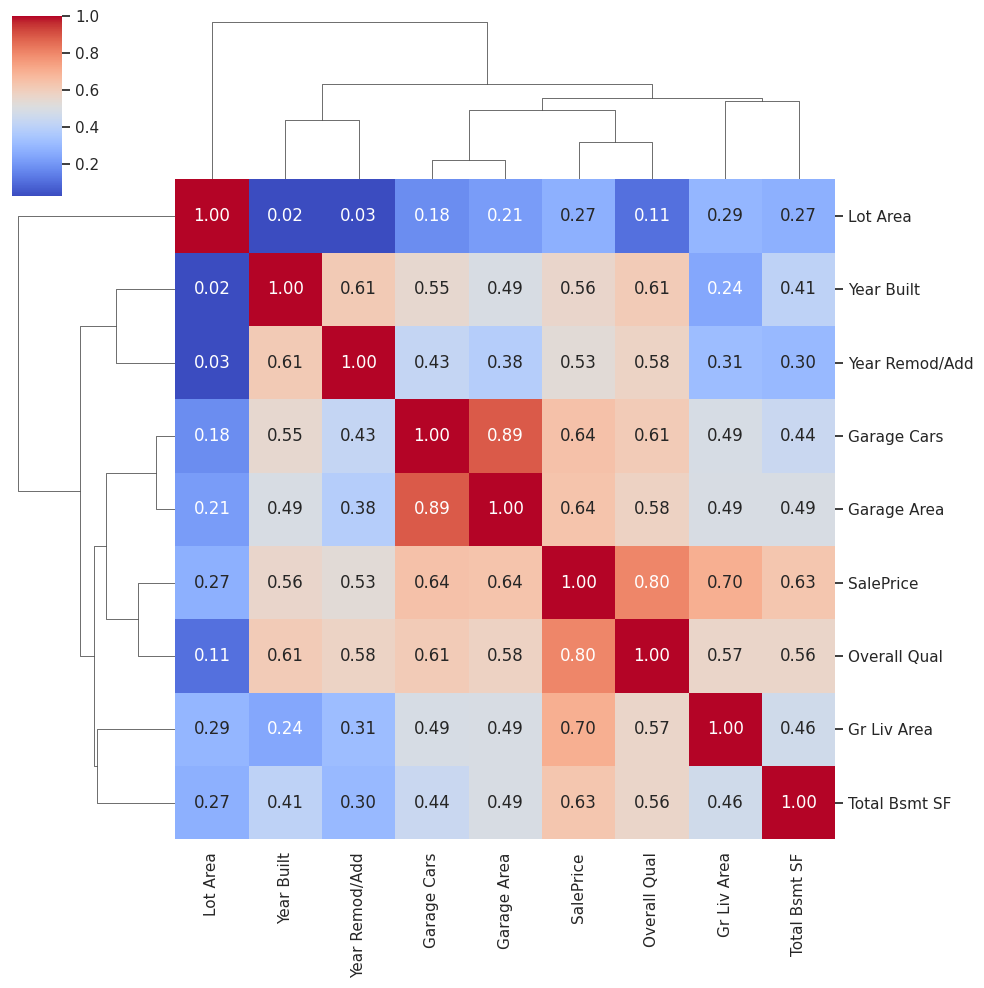

In [3]:
sns.clustermap(pearson_corr, cmap='coolwarm', annot=True, fmt='.2f', figsize=(10, 10))
plt.show()

### Réponse — Lecture des groupes de variables

On distingue globalement plusieurs groupes :

- un groupe **prix / qualité / surface** autour de `SalePrice`, `Overall Qual`, `Gr Liv Area` ;
- un groupe lié aux **espaces complémentaires** comme `Garage Area`, `Garage Cars` et `Total Bsmt SF` ;
- un groupe plus temporel avec `Year Built` et `Year Remod/Add`.

Cette organisation est cohérente avec le marché immobilier : une maison chère est souvent à la fois de bonne qualité, relativement grande et dotée d'espaces annexes valorisants.

## 3. Pair plot conditionnel selon la qualité

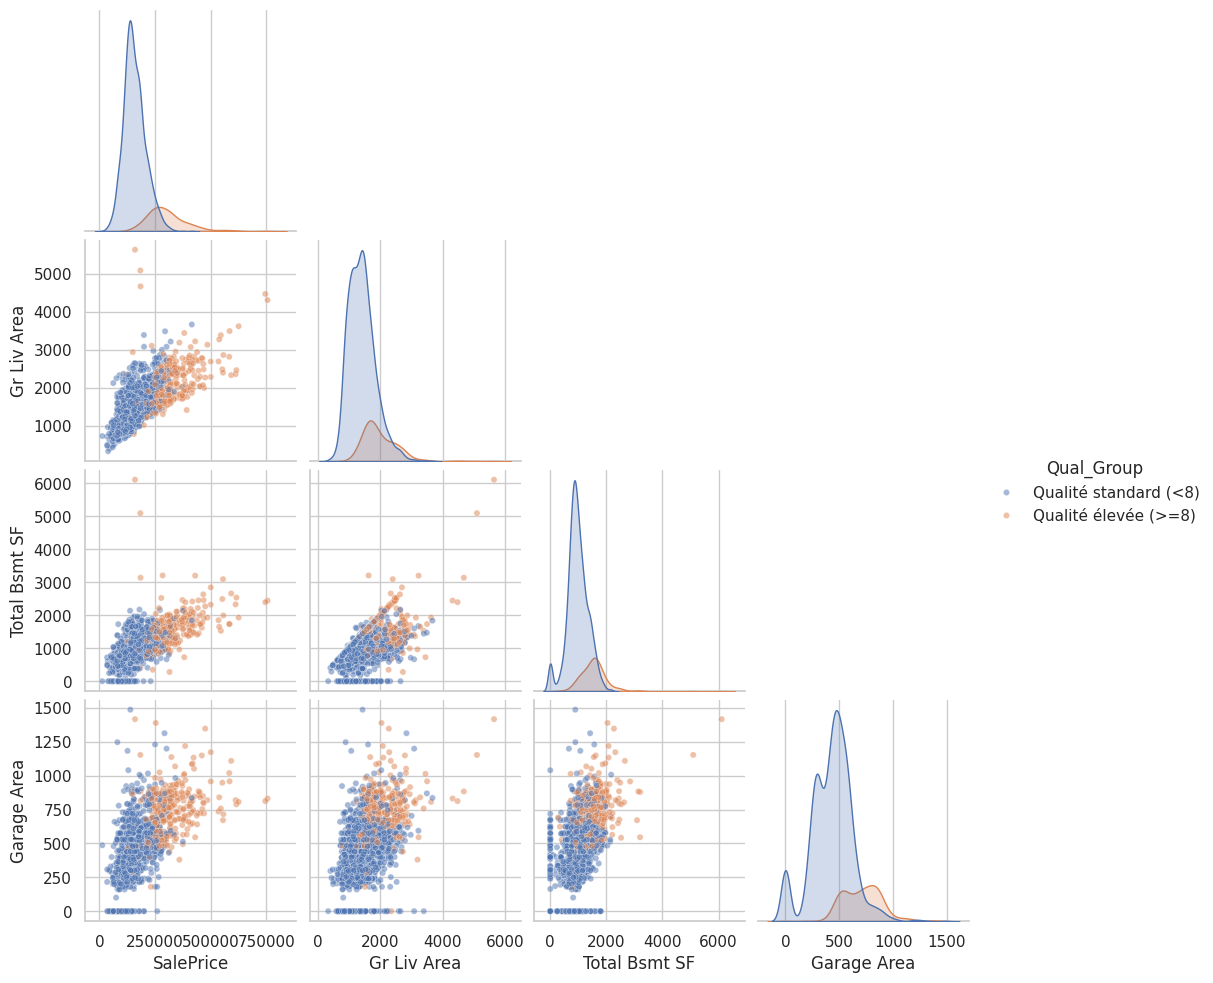

In [4]:
df_pair = df[['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Overall Qual']].dropna().copy()
df_pair['Qual_Group'] = np.where(df_pair['Overall Qual'] >= 8, 'Qualité élevée (>=8)', 'Qualité standard (<8)')

sns.pairplot(
    df_pair[['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Qual_Group']],
    hue='Qual_Group',
    corner=True,
    plot_kws={'alpha': 0.5, 's': 20}
)
plt.show()

### Réponse — Effet du niveau de qualité

Le pair plot montre que les maisons de **qualité élevée** forment souvent un nuage distinct :
- elles se situent plus fréquemment sur les niveaux élevés de prix,
- elles combinent souvent plus de surface habitable et plus d'espaces annexes.

Cela confirme que la **qualité** ne joue pas seule : elle renforce aussi l'effet des autres variables. Une grande maison n'est pas automatiquement très chère ; elle le devient davantage si elle est aussi de bonne qualité.

## 4. Localisation : surface habitable et prix selon le quartier

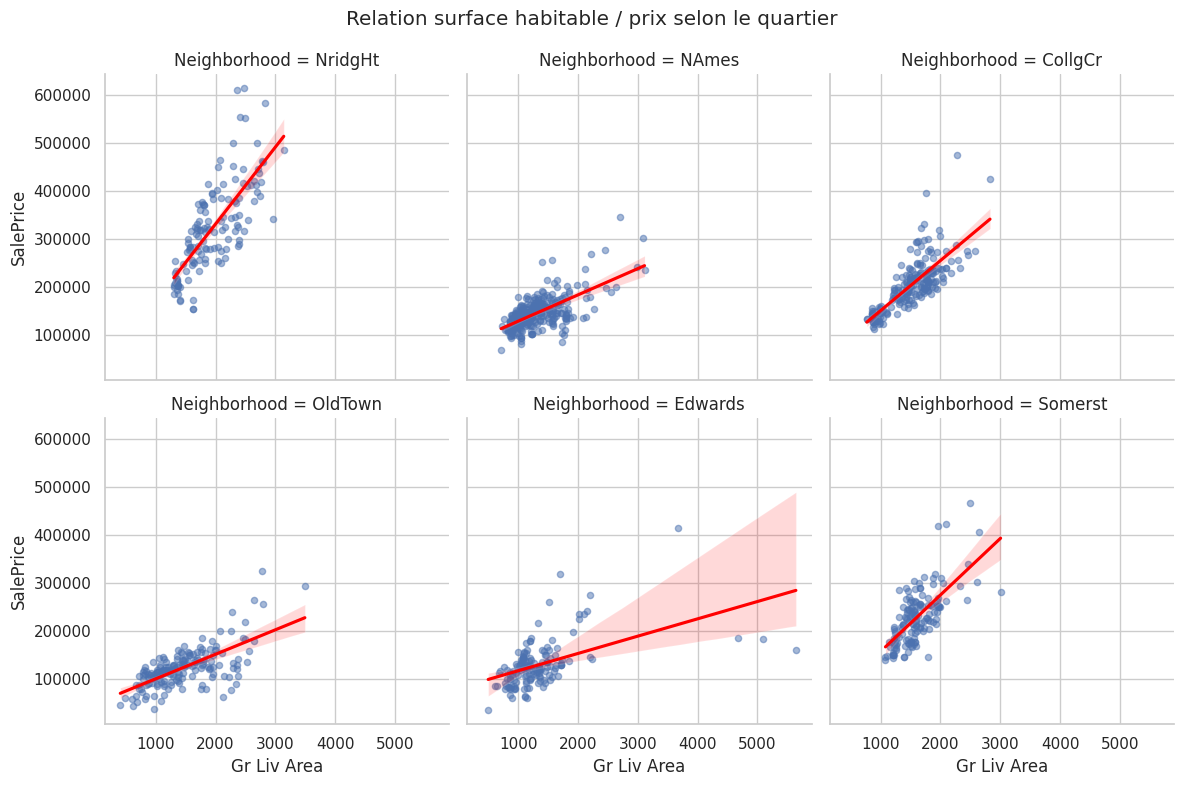

In [5]:
top6 = df['Neighborhood'].value_counts().head(6).index
df_loc = df[df['Neighborhood'].isin(top6)].copy()

g = sns.lmplot(
    data=df_loc,
    x='Gr Liv Area',
    y='SalePrice',
    col='Neighborhood',
    col_wrap=3,
    height=4,
    scatter_kws={'alpha':0.5, 's':20},
    line_kws={'color':'red'}
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Relation surface habitable / prix selon le quartier')
plt.show()

### Réponse — Rôle de la localisation

En séparant les graphiques par quartier, on voit que la relation entre surface et prix n'est pas identique partout. Cela montre que la **localisation module** la valorisation de la surface habitable.

J'utilise ici `Neighborhood` plutôt qu'une moyenne globale, car l'objectif est précisément de montrer qu'un même gain de surface n'a pas toujours la même traduction en prix selon le contexte local.

## 5. Détection de la multicolinéarité avec le VIF

In [7]:
X = df[['Overall Qual', 'Gr Liv Area', 'Year Built', 'Year Remod/Add', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Lot Area']].dropna().copy()

vif_df = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)

vif_df

,Variable,VIF
2,Year Built,8097.053348
3,Year Remod/Add,7920.167940
0,Overall Qual,43.548853
4,Garage Cars,34.224823
5,Garage Area,30.067255
1,Gr Liv Area,17.139167
6,Total Bsmt SF,11.034495
7,Lot Area,3.072678


### Réponse — Multicolinéarité

Plusieurs variables ont un VIF élevé, notamment :
- `Year Built` et `Year Remod/Add`,
- `Garage Cars` et `Garage Area`,
- ainsi que `Gr Liv Area` et `Total Bsmt SF` dans une moindre mesure.

Cela signifie qu'elles transportent une information partiellement redondante. C'est logique : une maison plus grande tend aussi à avoir un plus grand garage ou un sous-sol plus vaste.

Pour l'oral, cela permet de dire qu'en modélisation il faut éviter de mettre ensemble trop de variables très proches. On garde alors les plus interprétables, par exemple `Overall Qual`, `Gr Liv Area` et éventuellement une variable de localisation.

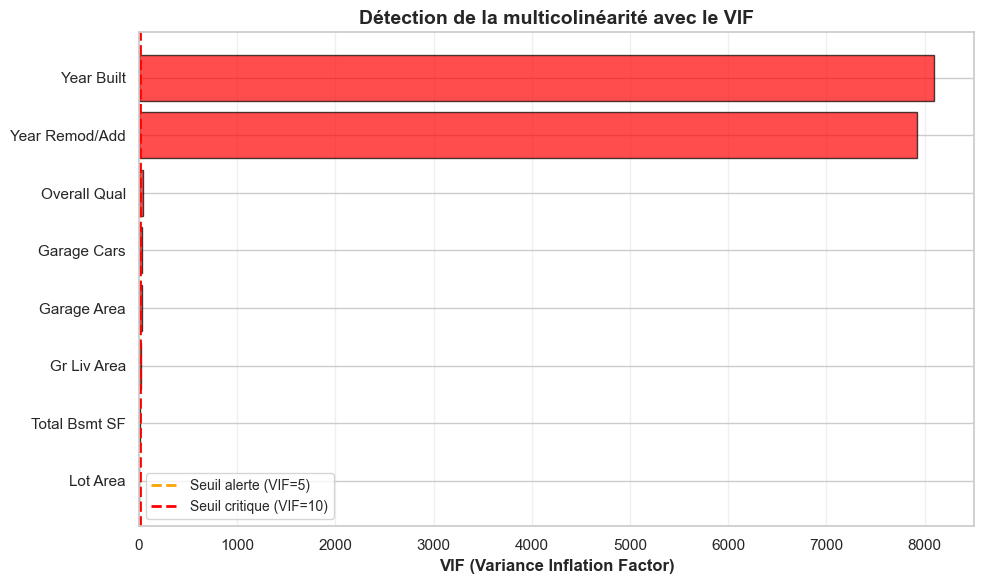


Interprétation :
  - VIF < 5 : pas de multicolinéarité problématique (vert)
  - 5 ≤ VIF < 10 : multicolinéarité modérée (orange)
  - VIF ≥ 10 : multicolinéarité forte (rouge)


In [8]:

# Visualisation des VIF
fig, ax = plt.subplots(figsize=(10, 6))
vif_sorted = vif_df.sort_values('VIF', ascending=True)
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_sorted['VIF']]

ax.barh(vif_sorted['Variable'], vif_sorted['VIF'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Seuil alerte (VIF=5)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Seuil critique (VIF=10)')

ax.set_xlabel('VIF (Variance Inflation Factor)', fontsize=12, fontweight='bold')
ax.set_title('Détection de la multicolinéarité avec le VIF', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("  - VIF < 5 : pas de multicolinéarité problématique (vert)")
print("  - 5 ≤ VIF < 10 : multicolinéarité modérée (orange)")
print("  - VIF ≥ 10 : multicolinéarité forte (rouge)")


## 6. Corrélations partielles

In [6]:
d = df[['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', 'Overall Qual']].dropna()

def partial_corr(data, x, y, controls):
    X = data[controls].values
    model_x = LinearRegression().fit(X, data[x].values)
    model_y = LinearRegression().fit(X, data[y].values)
    resid_x = data[x].values - model_x.predict(X)
    resid_y = data[y].values - model_y.predict(X)
    return np.corrcoef(resid_x, resid_y)[0, 1]

r_simple = pearsonr(d['Gr Liv Area'], d['SalePrice'])[0]
r_partial_bsmt = partial_corr(d, 'Gr Liv Area', 'SalePrice', ['Total Bsmt SF'])
r_partial_qual = partial_corr(d, 'Gr Liv Area', 'SalePrice', ['Overall Qual'])

print("Corrélation simple :", round(r_simple, 3))
print("Corrélation partielle en contrôlant Total Bsmt SF :", round(r_partial_bsmt, 3))
print("Corrélation partielle en contrôlant Overall Qual :", round(r_partial_qual, 3))

Corrélation simple : 0.699
Corrélation partielle en contrôlant Total Bsmt SF : 0.592
Corrélation partielle en contrôlant Overall Qual : 0.5


### Réponse — Corrélations partielles

La corrélation simple entre `Gr Liv Area` et `SalePrice` est forte, mais elle diminue lorsqu'on contrôle :
- `Total Bsmt SF`,
- puis surtout `Overall Qual`.

Autrement dit, une partie de la relation entre surface et prix s'explique aussi par le fait que les maisons plus grandes sont souvent de **meilleure qualité**. Cela renforce encore mon hypothèse centrale : la **qualité du bien** joue un rôle structurant dans la formation du prix.

## 7. Corrélations trompeuses et esprit critique

### Réponse — Interprétation critique

Une corrélation ne prouve pas à elle seule une causalité. Par exemple :

- `Lot Area` peut être corrélée au prix sans être le facteur principal ;
- certaines variables augmentent ensemble parce qu'elles décrivent des dimensions proches du logement ;
- la localisation peut modifier ou amplifier l'effet d'une variable comme la surface.

C'est pourquoi je retiens pour l'oral une lecture simple mais rigoureuse :

1. **la qualité du bien** explique fortement le prix ;
2. **la surface habitable** explique aussi le prix ;
3. **la localisation** module cette relation.

Cette conclusion est plus solide qu'une interprétation basée sur une seule corrélation isolée.